## Script to process multiple years using a Fourier Series Fit to the Temp Time Series, generate diagnostic plots, and some maps

### edit array of years to process below - roughly 1hr 50min for 4 years processing time (Fourier fit) 

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

###################
# helper functions
###################
def SummerStatsFourier(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_heat):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for SH summers)
        threshold: xarray for the 75th percentile threshold to use
        save_plot: save out a png of the time series with threshold, day of max, summer start/end shown
        calc_tmax: should the day of max temp during summer be calculated (slows processing)
        calc_heat: should the accumulated heat during summer be calculated (slows processing), includes mean temp and mean HS temp
        
    Returns:
        start day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed above threshold (75th percentile)
        end day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed below threshold (75th percentile) 
        day with max temp: during the summer period, the day that had the highest mean daily t2m 
        accumulated heat in summer: sum of degree days above threshold during summer, 0 if none
        summer length: number of days the smoothed fit to the t2m data is above threshold, 0 if none
        rmse: root mean squared error of Fourier fit to temperature time series
        **** r2: R-squared value for Fourier fit [IS THIS POSSIBLE???]
        mean temp: the mean temperature in K for the summer period, 0 if there was no time above threshold
        mean HS temp: the mean temperature in K for the days above threshold during summer (positive days)
        
    Example:
        start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStats(temps, temps_next, thresh, True, True, False)

    '''

    # default values
    first_day = 0 
    last_day = 0
    tmax_day = 0 
    summer_heat = 0 
    summer_length = 0
    rmse = 0.0
    r_squared = 0.0 # keeping for backward compat with the poly fit outputs
    mean_t = 0
    mean_hs = 0

    # split method based on NH or SH

    ######
    # Northern Hemisphere (uses current year only)
    if temp_data.lat.values >= 0:
        # extract DOY and T2m values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values

        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
    
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
    
        # use fit to get stats
        summer_length = np.count_nonzero(y_lp >= threshold.values)
        summer_days = np.where(y_lp >= threshold.values)[0]

        # deal with those that didn't have any days above threshold
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(temp_data.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days 
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (temp_data[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((temp_data[(first_day):(last_day+1)].argmax() + 1) + first_day)        
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save mean temp
                nh_summ = temp_data[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(nh_summ.where(nh_summ.values >= threshold.values).sum())
                days_above_thresh = nh_summ.where(nh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(nh_summ.where(nh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(nh_summ) > 0:
                    mean_t = nh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values

                
    
    ######
    # Southern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'
        sh_yr = ds_two.sel(time=slice(startdate,enddate))
        
        # DOY (relative to July 1) and T2m values for those days
        x1 = np.arange(1,len(sh_yr.time)+1) 
        y1 = sh_yr.values
        
        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
        
        # create some x values for plotting  fit
        x_values = np.linspace(min(x1), max(x1), 365) 
        summer_length = np.count_nonzero(y_lp >= threshold.values)
        summer_days = np.where(y_lp >= threshold.values)[0]

        # check if summer length is 0
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(sh_yr.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days but note these are relative to July 1
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of  fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1           
    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (sh_yr[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((sh_yr[(first_day):(last_day+1)].argmax() + 1) + first_day)  
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save the mean temp of summer
                sh_summ = sh_yr[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(sh_summ.where(sh_summ.values >= threshold.values).sum())
                days_above_thresh = sh_summ.where(sh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(sh_summ.where(sh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(sh_summ) > 0:
                    mean_t = sh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values
                
                

                
    # make and save plot if desired
    ##
    ##
    if save_plot:
        cell_lat = temp_data.lat.values
        cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,np.mean(y_lp)), fontsize=18)
        plt.annotate('75th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)
        plt.annotate('RMSE = '+str(np.round(rmse,2)), xy=(0, np.min(y1)), fontsize=18)
        plt.annotate('Mean = '+str(np.round(mean_t,2))+'K', xy=(last_day-5, mean_t-1), fontsize=12)

        if calc_tmax:
            # add annotation for tmax_day
            plt.annotate('Tmax day '+str(tmax_day), xy=(tmax_day,np.max(y1)), fontsize=12)

        if cell_lat < 0:
            # SH days are relative to July 1
            plt.xlabel('DOY (' + str(yr) + ') relative to July 1')
        else:
            plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
        plt.legend()
        plt.savefig("fourierfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        plt.show()
    
    # return
    return int(first_day), int(last_day), int(tmax_day), float(summer_heat), int(summer_length), float(rmse), float(r_squared), float(mean_t), float(mean_hs)


# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.t2m[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.t2m[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

## Need to play around with FFT for a bit to understand how to get coefficients/regression I need

In [2]:
input_year = 2023

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
else:
    file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/*.nc'
else:
    file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")

In [3]:
curr

<xarray.DataArray 't2m' (time: 365)> Size: 1kB
array([277.85846, 276.25998, 276.00104, 277.60065, 279.9721 , 281.0007 ,
       280.31857, 278.873  , 279.47437, 280.06107, 278.41147, 279.9854 ,
       282.21384, 281.75357, 279.89413, 279.17282, 278.9146 , 278.79837,
       276.04105, 276.57327, 275.25165, 275.75153, 275.814  , 276.95996,
       278.01096, 277.17386, 277.7211 , 277.7685 , 273.12265, 271.1428 ,
       272.33774, 274.49155, 276.7173 , 278.5231 , 279.65396, 279.75024,
       279.16632, 279.54248, 277.18427, 278.0396 , 279.84296, 277.13876,
       276.94293, 278.1664 , 275.91284, 274.40744, 275.97165, 275.79068,
       277.22305, 277.44992, 278.80453, 278.39993, 273.55386, 270.00476,
       269.04343, 270.9241 , 273.843  , 273.65262, 273.93497, 273.19577,
       276.2947 , 274.91306, 275.83002, 276.2111 , 276.40756, 277.67606,
       277.53235, 277.85043, 278.95877, 277.55777, 278.0136 , 278.23083,
       276.64005, 277.74533, 277.27332, 278.59186, 281.05167, 281.85995,
       281.66544, 281.23468, 280.07193, 280.4364 , 276.94815, 276.16196,
       276.29678, 277.9591 , 281.5167 , 282.8868 , 280.32413, 278.85092,
       277.52853, 276.13004, 276.5377 , 277.10837, 277.7906 , 280.22122,
       282.14047, 280.51785, 281.35464, 280.05524, 279.14825, 277.93423,
       278.56042, 278.32425, 280.4774 , 280.44992, 277.87436, 277.9033 ,
       278.54333, 278.06485, 278.46017, 280.83408, 282.09213, 280.59677,
       281.53647, 281.60342, 283.12045, 285.525  , 288.0834 , 286.6064 ,
...
       290.55612, 290.57935, 287.8285 , 287.90405, 288.3777 , 289.86258,
       289.98816, 288.29193, 287.83725, 285.42276, 285.68628, 286.3494 ,
       286.41513, 286.9586 , 285.49832, 287.1647 , 285.92157, 285.39078,
       284.61365, 283.3901 , 283.70346, 284.1682 , 284.1642 , 284.01102,
       284.54562, 287.0187 , 287.87085, 288.75577, 288.83545, 288.57388,
       285.0137 , 285.00912, 283.6874 , 284.8153 , 286.61334, 286.90622,
       286.7423 , 283.5742 , 284.51044, 286.56866, 286.1038 , 284.00394,
       284.21335, 281.88513, 279.012  , 279.43185, 278.595  , 278.25937,
       276.46008, 277.41132, 278.22855, 278.32413, 279.29993, 282.69046,
       283.38138, 284.72134, 283.85654, 282.72354, 282.26334, 280.00003,
       279.94705, 280.32397, 281.4172 , 279.9847 , 280.00513, 277.0347 ,
       276.68573, 276.3812 , 276.88474, 278.6555 , 280.90344, 278.45612,
       278.9112 , 279.64758, 277.80154, 276.67484, 276.07535, 276.47623,
       276.6493 , 275.4898 , 275.32953, 275.46136, 275.99756, 277.08365,
       277.91202, 278.80984, 281.56595, 280.499  , 278.0072 , 275.9988 ,
       275.65854, 277.4133 , 278.71542, 277.39636, 276.89432, 279.1982 ,
       279.895  , 278.5417 , 278.93372, 280.1862 , 281.07965, 281.59555,
       281.27   , 280.6691 , 276.12766, 275.86334, 278.7772 , 281.24524,
       281.18582, 282.39438, 282.97516, 283.1307 , 279.90363],
      dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    realization  int64 8B 0
    lat          float64 8B 49.25
    lon          float64 8B -123.0
Attributes:
    long_name:              2 metre temperature
    units:                  K
    standard_name:          air_temperature
    comment:                near-surface (usually, 2 meter) air temperature
    cds_magics_style_name:  near-surface-air-temperature
    type:                   real

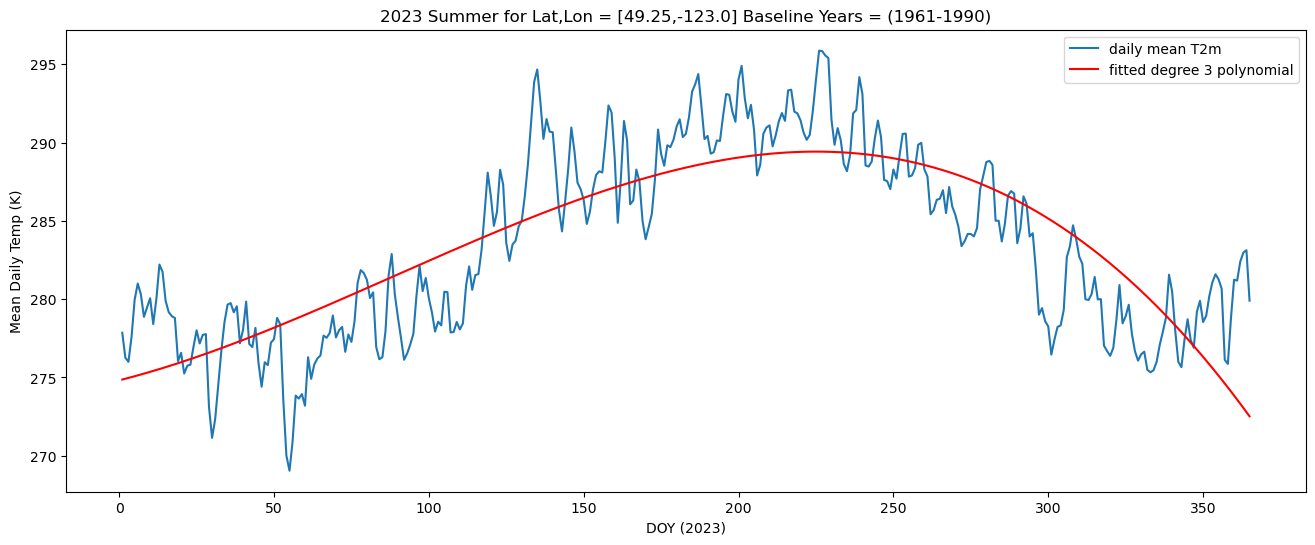

In [4]:
cell_lat = curr.lat.values
cell_lon = curr.lon.values
yr = curr.time.dt.year.values[0]
x1 = curr.time.dt.dayofyear.values
y1 = curr.values 

# polynomial fit, degree 3 as in Wang et al 2021
coefs = np.polyfit(x1, y1, 3)
poly = np.poly1d(coefs)

plt.figure(figsize=(16,6))
plt.plot(x1,y1, label='daily mean T2m')
plt.plot(x1, poly(x1), label='fitted degree 3 polynomial', color='red')
plt.xlabel('DOY (' + str(yr) + ')')
plt.ylabel('Mean Daily Temp (K)')
plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")
plt.legend()
plt.show()

### I believe it needs to be normalized by subtracting the mean

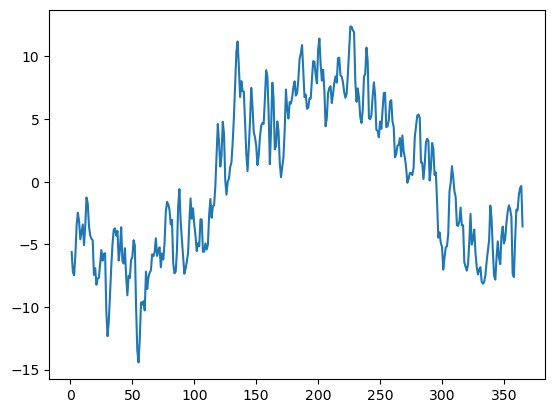

In [5]:
y_norm = y1 - np.mean(y1)
plt.plot(x1, y_norm)

In [6]:
# perform DFT of temp data and output first 10 coefficients (Re + Im parts)
coef = fft(y_norm)
coef[1:10]

array([-1269.2488  +535.79346j ,   194.61826  -79.65817j ,
         214.98663  -73.17946j ,    15.217267 -58.751312j,
         170.41653  +66.07536j ,    51.171997 -79.647156j,
        -124.8546   +61.684814j,   109.80795  +59.232815j,
          65.69086  +35.298668j], dtype=complex64)

#### help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html

In [7]:

# to get the right variance, we need to normalize coef by N.
Zfft = coef/len(y_norm)

# next, we calculate the power: the square of absolute value of complex fourier transform
# np.abs returns real value
Ck2 = np.abs(Zfft)**2

# alternative way to compute power over half the FFT output
#Ck2 = 2*np.abs(Zfft[0:int(len(y1)/2)+1])**2

Ck2[1:10]

array([14.247082  ,  0.3319324 ,  0.38712323,  0.02764708,  0.25076184,
        0.0672715 ,  0.14557093,  0.1168423 ,  0.04174356], dtype=float32)

In [8]:
# checking the variance compared to the total variance in our spectrum
# i.e, checking Parseval's Theorem

# actual variance of your data
var_actual = np.var(y_norm)

# variance in your spectrum, it should be close to the actual variance of your data
var_spectrum = np.sum(Ck2)

print(np.round(var_actual,5), np.round(var_spectrum,5))

35.69989 35.6999


#### those are very similar - proceed! (note that this was not the case until I subtracted the mean above)

(-0.5, 20.0)

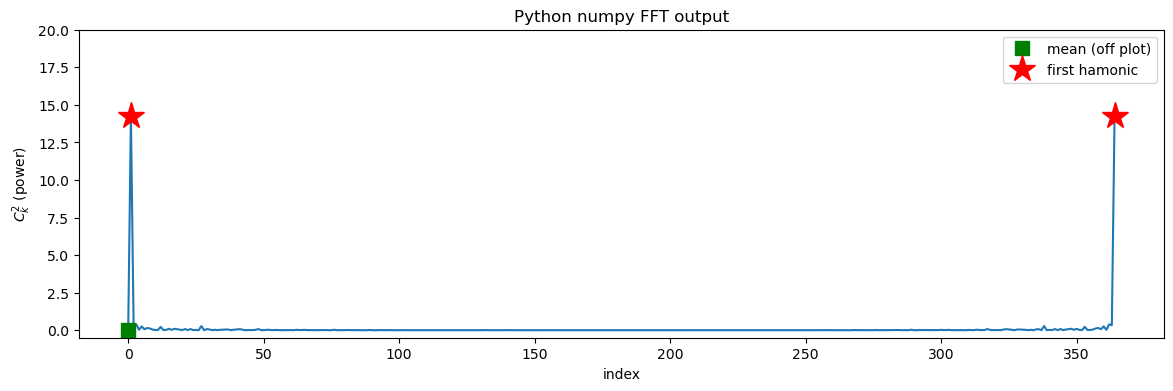

In [9]:
# plot the FFT power

plt.figure(figsize=(14,4))

# plot blue line
plt.plot(np.arange(0,np.size(Zfft)),np.abs(Zfft)**2)

# plot markers
plt.plot(0,np.abs(Zfft[0])**2.,'sg',markersize=10,label='mean (off plot)')
plt.plot(1,np.abs(Zfft[1])**2.,'*r',markersize=20,label='first hamonic')
plt.plot(np.size(Zfft)-1,np.abs(Zfft[-1])**2.,'*r',markersize=20)

plt.xlabel('index')
plt.ylabel('$C_k^2$ (power)')

plt.title('Python numpy FFT output')
plt.legend()

plt.ylim(-.5,20)
#plt.xlim(-5,365+5)

### I think that plot shows that the daily and annual cycle dominate but there are smaller peaks visible that are likely the ones we are looking for in a seasonal cycle

Text(0.5, 1.0, 'Normalized Discrete Power Spectrum')

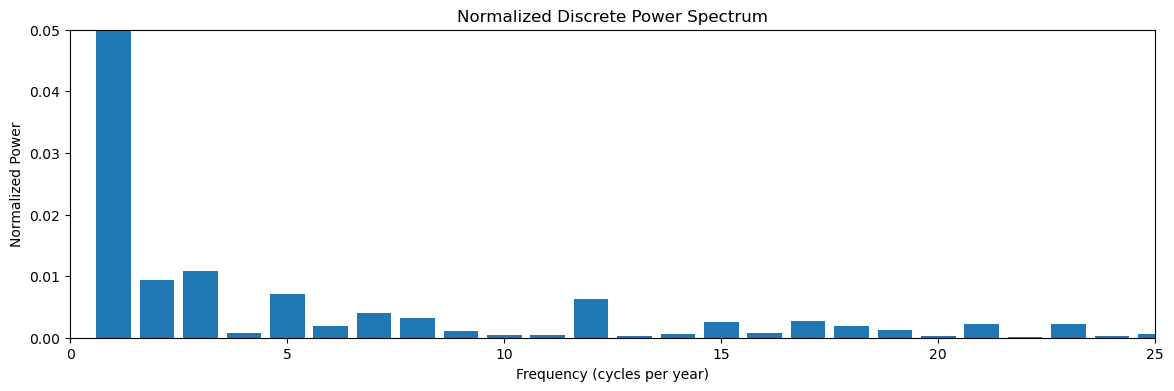

In [10]:
# combine symmetric parts of the FFT and plot the power spectrum as a function of frequency

# create frequency variable for plotting
freq = np.arange(0,int(len(y1)))
#print(freq)

# plot power just up to freq = 25 cycles per year
plt.figure(figsize=(14,4))
plt.bar(freq,Ck2/np.sum(Ck2))
plt.ylabel('Normalized Power')
plt.xlabel('Frequency (cycles per year)')
plt.xlim(0,25)
plt.ylim(0,0.05)
plt.title('Normalized Discrete Power Spectrum')

### The top 4 in terms of power all have freq $\le$ 5 cycles per year, but for a seasonal pattern we will only use the lowest 4 (although looks like we could use the lowest 3 in this example)

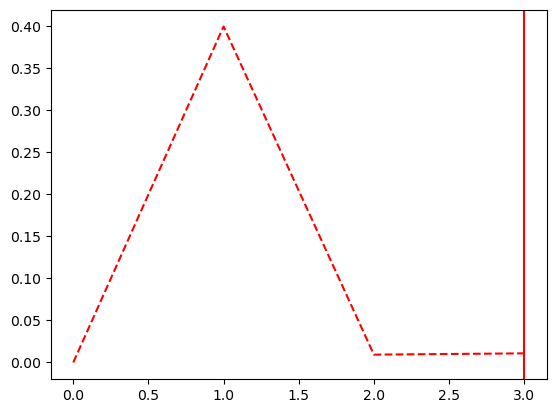

In [11]:
# plot spectrum and now we will only retain the first 4 harmonics (which includes the mean)

# plot vertical line showing the frequency cut-off
plt.axvline(freq[3],color ='r', linewidth = 1.5)

# compute normalized power
A = Ck2/np.sum(Ck2)

# set power to zero at frequencies above 2 cycles per year
A[4::] = 0.

# plot power for lowest frequencies
plt.plot(freq[0:4],A[0:4],'--r')

In [12]:
# low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
# Note that we use the unnormalized FFT output here as this is what we want to plug into our inverse fft.

Z_lp = np.copy(coef)
Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
Z_lp[:5]

array([ 6.6223145e-03  -0.j     , -1.2692488e+03+535.79346j,
        1.9461826e+02 -79.65817j,  2.1498663e+02 -73.17946j,
        0.0000000e+00  +0.j     ], dtype=complex64)

### Now apply inverse Fourier transform after setting all harmonics above the 4th to zero, and then plot it

In [13]:
# apply inverse fourier transform to convert back to time domain (just want the real part)
y_norm_lp = np.real(np.fft.ifft(Z_lp))

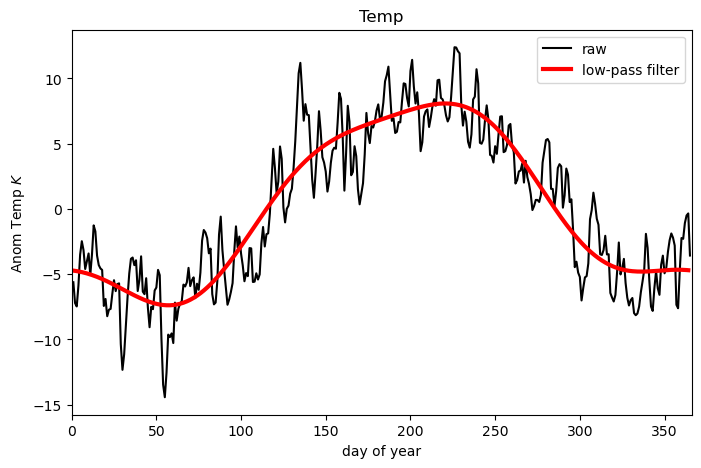

In [14]:
# plot FFT fit on top of raw (normalized) data
plt.figure(figsize=(8,5))
plt.plot(x1,y_norm,'-k',label='raw')
plt.ylabel('Anom Temp $K$')
plt.xlabel('day of year')
plt.xlim(0,366)
plt.title('Temp')

#  plot low-pass time series
plt.plot(np.arange(0,len(y_norm)), y_norm_lp ,'-r',linewidth = 3, label ='low-pass filter')

plt.legend()

In [17]:
# get polynomial fit for overlay
coefs = np.polyfit(x1, y1, 3)
poly = np.poly1d(coefs)

# add in R^2 and RMSE for poly fit
ymean = np.mean(y1)
ss_total = np.sum((y1 - ymean)**2)
ss_res = np.sum((y1 - poly(x1))**2)
rmse = np.sqrt(ss_res/365.0)
r_squared = 1 - (ss_res / ss_total)

# RMSE for Fourier fit
rmse_fourier = np.sqrt(np.sum((y1-y_lp)**2)/365.0)

# print them out
print("Poly fit RMSE = "+str(np.round(rmse,4)))
print("Fourier fit RMSE = "+str(np.round(rmse_fourier,6)))



Poly fit RMSE = 3.4497
Fourier fit RMSE = 2.401587


In [81]:
np.sqrt(np.sum((y1-y_lp)**2)/365)


np.float32(2.441553)

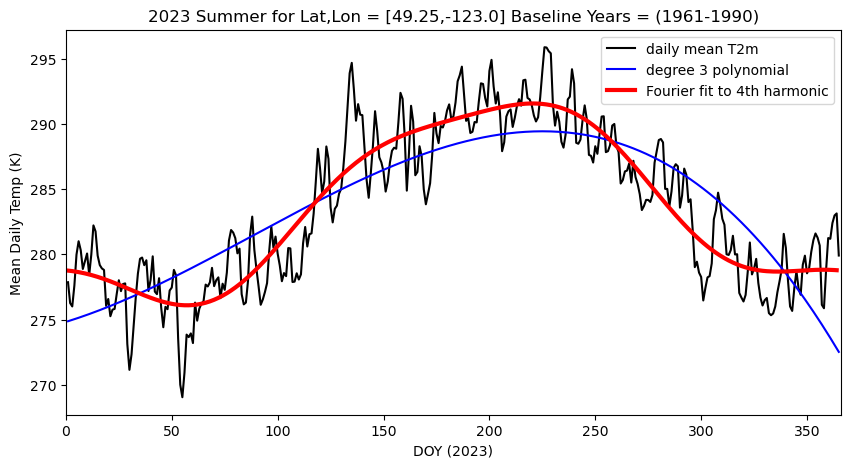

In [16]:
# same as above but add back in th4e original mean temp
#y = y_norm + np.mean(y1)
y_lp = y_norm_lp + np.mean(y1)

# plot FFT fit on top of raw (normalized) data
plt.figure(figsize=(10,5))
plt.plot(x1,y1,'-k',label='daily mean T2m')
plt.plot(x1, poly(x1), label='degree 3 polynomial', color='blue')
plt.xlim(0,366)
plt.xlabel('DOY (' + str(yr) + ')')
plt.ylabel('Mean Daily Temp (K)')
plt.title(str(yr) + " Summer for Lat,Lon = [" +str(cell_lat)+","+str(cell_lon)+ "] Baseline Years = (1961-1990)")

#  plot low-pass time series
plt.plot(np.arange(0,len(y_lp)), y_lp ,'-r',linewidth = 3, label ='Fourier fit to 4th harmonic')

plt.legend()

### For this example (Vancouver 2023) the Fourier fit is a lot better! RMSE for the Fourier fit is considerably better too
- check using only 1, 2, or 3 harmonics to be certain
- code up summer stats function to use fourier fit and produce parallel set of summer metrics via Fourier for comparison

#### first three harmonics

In [18]:
# low-pass filter: retain only the mean and the first TWO harmonics, set all other frequencies to zero
# Note that we use the unnormalized FFT output here as this is what we want to plug into our inverse fft.

Z_lp_3H = np.copy(coef)
Z_lp_3H[3:-2:] = 0.0  # we have to set both the positive and negative frequencies to zero
print(Z_lp_3H[:5])

# apply inverse fourier transform to convert back to time domain (just want the real part)
y_norm_lp_3H = np.real(np.fft.ifft(Z_lp_3H))

[ 6.6223145e-03  -0.j      -1.2692488e+03+535.79346j
  1.9461826e+02 -79.65817j  0.0000000e+00  +0.j
  0.0000000e+00  +0.j     ]


#### first two (mean and 1st)

In [19]:
Z_lp_2H = np.copy(coef)
Z_lp_2H[2:-1:] = 0.0  # we have to set both the positive and negative frequencies to zero
print(Z_lp_2H[:5])

# apply inverse fourier transform to convert back to time domain (just want the real part)
y_norm_lp_2H = np.real(np.fft.ifft(Z_lp_2H))

[ 6.6223145e-03  -0.j      -1.2692488e+03+535.79346j
  0.0000000e+00  +0.j       0.0000000e+00  +0.j
  0.0000000e+00  +0.j     ]


#### mean only! (1st harmonic)

In [20]:
Z_lp_1H = np.copy(coef)
Z_lp_1H[1::] = 0.0  # we have to set both the positive and negative frequencies to zero
print(Z_lp_1H[:5])

# apply inverse fourier transform to convert back to time domain (just want the real part)
y_norm_lp_1H = np.real(np.fft.ifft(Z_lp_1H))

[0.00662231-0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j]


#### 1-4th Harmonic and raw (normalized) data plot

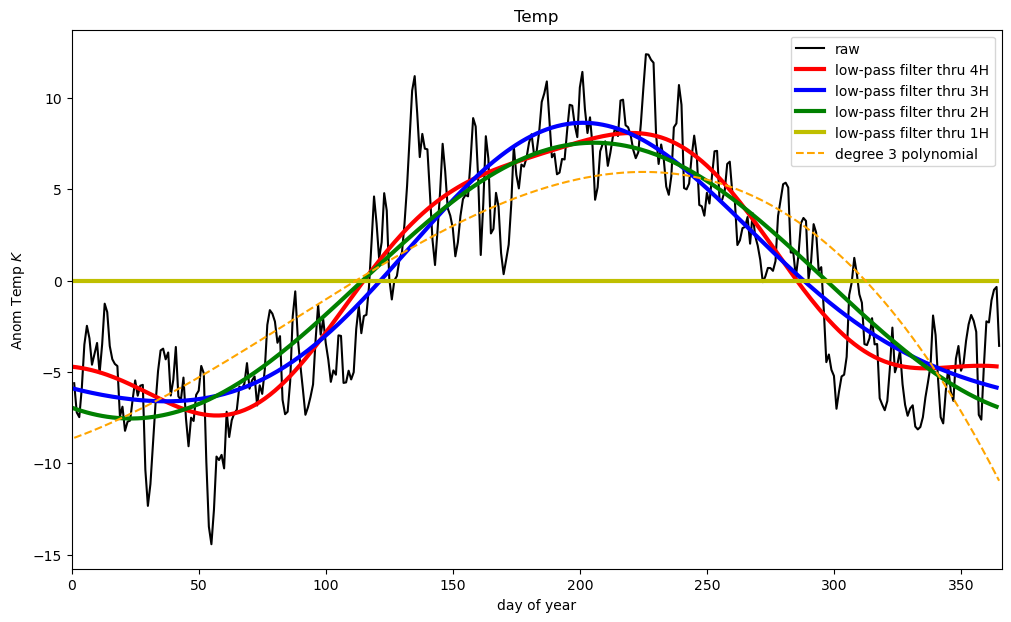

In [21]:

# plot FFT fits on top of raw (normalized) data
plt.figure(figsize=(12,7))
plt.plot(x1,y_norm,'-k',label='raw')
plt.ylabel('Anom Temp $K$')
plt.xlabel('day of year')
plt.xlim(0,366)
plt.title('Temp')

#  thru 4th harmonic
plt.plot(np.arange(0,len(y_norm)), y_norm_lp ,'-r',linewidth = 3, label ='low-pass filter thru 4H')

#  thru 3rd Harmonic
plt.plot(np.arange(0,len(y_norm)), y_norm_lp_3H ,'-b',linewidth = 3, label ='low-pass filter thru 3H')

#  thru 2nd Harmonic
plt.plot(np.arange(0,len(y_norm)), y_norm_lp_2H ,'-g',linewidth = 3, label ='low-pass filter thru 2H')

#  thru 1st Harmonic
plt.plot(np.arange(0,len(y_norm)), y_norm_lp_1H ,'-y',linewidth = 3, label ='low-pass filter thru 1H')

# ploynomial
plt.plot(x1, (poly(x1)-np.mean(y1)), color='orange',linestyle='dashed',label='degree 3 polynomial')


plt.legend()

In [22]:
# same as above but add back in the original mean temp so on the same scale as raw data
y_lp_3H = y_norm_lp_3H + np.mean(y1)
y_lp_2H = y_norm_lp_2H + np.mean(y1)
y_lp_1H = y_norm_lp_1H + np.mean(y1)

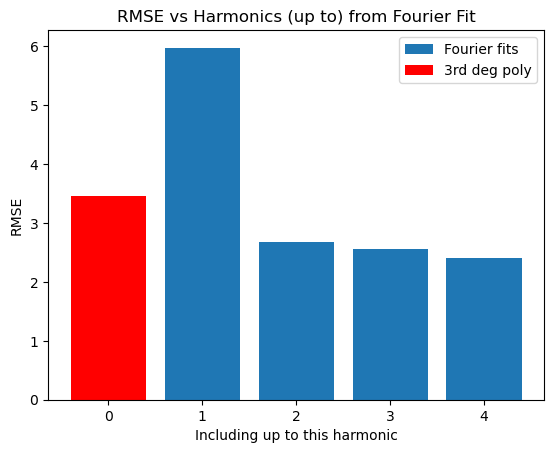

In [23]:
# RMSE for Fourier fits
rmse_fourier_4H = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
rmse_fourier_3H = np.sqrt(np.sum((y1-y_lp_3H)**2)/365.0)
rmse_fourier_2H = np.sqrt(np.sum((y1-y_lp_2H)**2)/365.0)
rmse_fourier_1H = np.sqrt(np.sum((y1-y_lp_1H)**2)/365.0)
rmse_poly = rmse

# assemble data frame for plotting
fourier_res = pd.DataFrame({'Harmonic':[1,2,3,4],'RMSE':[rmse_fourier_1H, rmse_fourier_2H, rmse_fourier_3H, rmse_fourier_4H]})
plt.bar(fourier_res.Harmonic, fourier_res.RMSE, label="Fourier fits")
plt.bar(0,rmse_poly, color='red', label="3rd deg poly")
plt.xlabel("Including up to this harmonic")
plt.ylabel("RMSE")
plt.xticks([0,1,2,3,4])
plt.title("RMSE vs Harmonics (up to) from Fourier Fit")
plt.legend()
plt.show()

# print them out
# print("Poly fit RMSE = "+str(np.round(rmse,4)))
# print("Fourier fit RMSE = "+str(np.round(rmse_fourier,6)))

#### OK, seems like improvement up to including the mean and one harmonic over polynomial, with incremental improvement up to including the mean plus 3 harmonics, after which we'd be fitting more frequent signals than seasonal

### time to add in the threshold temp and identify the start/end/length of summer

#### Load baseline 75% percentile values per grid cell

In [2]:
# get baseline
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values


array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]], shape=(721, 1440))

In [25]:
# get threshold for this location
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
print(thresh)

<xarray.DataArray 't2m' ()> Size: 8B
array(286.88797)
Coordinates:
    lat       float64 8B 49.25
    lon       float64 8B -123.0
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K


In [26]:
# find length, start, and end using up to 4th harmonic
# use fit to get stats
summer_length = np.count_nonzero(y_lp >= thresh.values)
summer_days = np.where(y_lp >= thresh.values)[0]
print(summer_length)

131


In [27]:
# create some x values for plotting polynomial fit
x_values = np.linspace(min(x1), max(x1), 365) 

# deal with those that didn't have any days above threshold
if summer_length == 0:
    first_day = 0
    last_day = 0
    if calc_tmax:
        # day with max temp isn't above threshold but still want the value so can be any day of the year
        tmax_day = int(y1.argmax() + 1)
    if calc_heat:
        # determine accumulated heat over summer as sum of degree days above threshold
        # in this case there are none
        summer_heat = 0
else:
    # otherwise can get start/end days 
    first_day = int(x_values[min(summer_days)])
    #OLD:# last_day = int(x_values[max(summer_days)])

    # end day comes after first day so find next crossing of poly fit
    # this is to be careful to not count until the end of a double crossing
    end_window = np.where((y_lp[first_day:365]) < thresh.values)

    # if it does cross back below threshold before the end of the "year"
    if np.count_nonzero(end_window):
        last_day = end_window[0][0] + first_day

    # otherwise it never crosses back below threshold for the "year"
    # so the last day is day 365
    else:
        last_day = 365

# day with max temp that is in summer period
if first_day == last_day: #only one day of summer
    tmax_day = first_day
else:
    # if summer_length is 0 then we already grab the day of max temp in the year
    # but the day of max can also be the last day of the year so have to special case
    if (y1[(first_day):(last_day+1)]).size == 0:
        tmax_day = last_day
    else:         
        tmax_day = int((y1[(first_day):(last_day+1)].argmax() + 1) + first_day)        

# determine accumulated heat over summer as sum of degree days above threshold
# also save mean temp
nh_summ = curr[(first_day):(last_day+1)]

# total area relative to zero for regions above threshold line
above_thresh = float(nh_summ.where(nh_summ.values >= thresh.values).sum())
days_above_thresh = nh_summ.where(nh_summ.values >= thresh.values).count()

# area below threshold line to be subtracted
thresh_heat = float(nh_summ.where(nh_summ.values >= thresh.values).count()) * thresh.values

# calculate difference to get only the area between threshold and data
summer_heat = above_thresh - thresh_heat

# if there is a summer we can get the mean temp for the whole summer and the mean HS temp
if len(nh_summ) > 0:
    mean_t = nh_summ.values.mean()
    mean_hs = float(above_thresh/days_above_thresh) - thresh.values

# print out all the metrics

# summer length is the span between first and last + 1 to include the end day
summer_length = last_day - first_day + 1    
print(first_day, last_day, summer_length, tmax_day, summer_heat, mean_t, mean_hs)

138 268 131 226 399.51611328125 289.73587 3.567108154296875


#### for this example - big difference in start/end day, but length is similar to poly fit, and so is $T_{mean}$

#### Time to implement the summer stats function using Fourier!

### Updated the function at start of script to include Fourier fit - now testing on specific lat/lon to confirm success before processing whole global grid

In [28]:
# get baseline (again) to keep code blocks together
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values


array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]], shape=(721, 1440))

In [3]:
# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = c_75.lat.values[:num_lat]
loop_lons = c_75.lon.values[:num_lon]

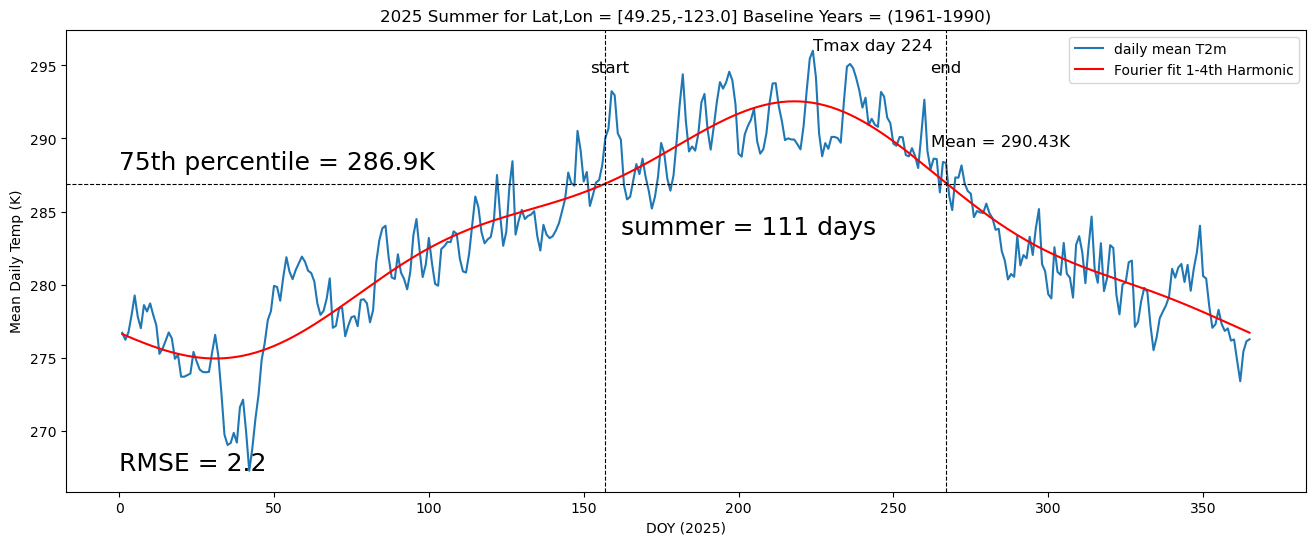

(157,
 267,
 224,
 399.99737548828125,
 111,
 2.2005820274353027,
 0.0,
 290.4295959472656,
 3.921542896943947)

In [6]:
# testing mean temp addition
input_year = 2025

# get this year and next year's daily mean t2m data
if input_year <= 1990:
    file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
else:
    file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
ds = xr.open_mfdataset(file_path)

if input_year+1 <= 1990:
    file_path_next = '../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/*.nc'
else:
    file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/*.nc'
dsnext = xr.open_mfdataset(file_path_next)

# remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
ds = HandleLeapYears(ds)
dsnext = HandleLeapYears(dsnext)

# load into memory to speed up the summer stats processing
ds.load()
dsnext.load()

#test for Vancouver
input_lat = 49.246
input_lon = -123.116
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

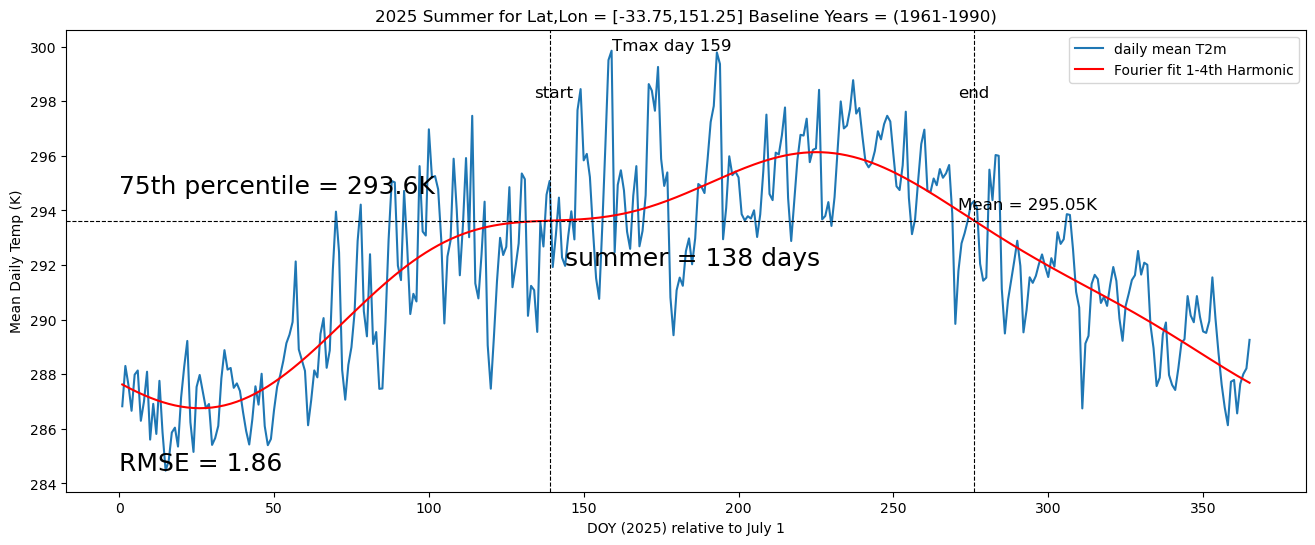

(139,
 276,
 159,
 239.8262939453125,
 138,
 1.859622836112976,
 0.0,
 295.0464172363281,
 2.2840599423362846)

In [7]:
# test for Sydney
input_lat = -33 - 52/60 - 4/3600
input_lon = 151.25
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

### A few more cities to use for presentations

#### Guangzhou 2023

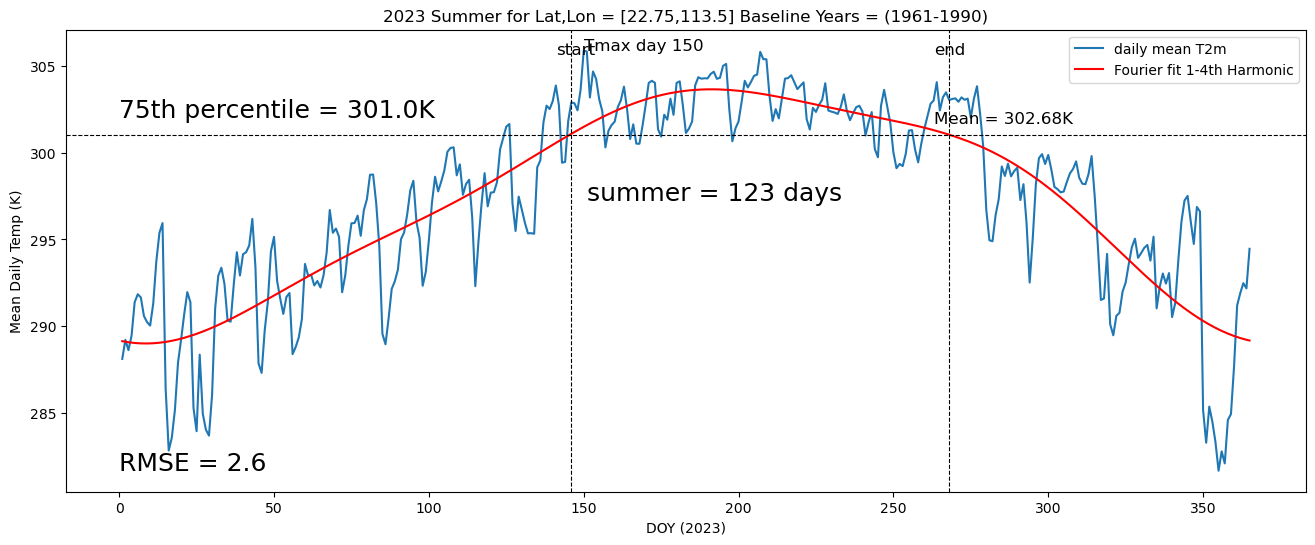

(146,
 268,
 150,
 219.496826171875,
 123,
 2.5988669395446777,
 0.0,
 302.683837890625,
 2.070724775206372)

In [32]:
# test for Guangzhou
# 112° 57′ to 114° 03′ E longitude and 22° 26′ to 23° 56′ N latitude
input_lat = 22 + 45/60 # midpoint of those latitude values above
input_lon = 113.5 # midpoint of those longitudes above
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

In [11]:
thresh - 273.15

# this is 5.87 degrees warmer than they consider as the threshold for summer (22 C for at least 5 days)

<xarray.DataArray 't2m' ()> Size: 8B
array(27.87160645)
Coordinates:
    lat       float64 8B 22.75
    lon       float64 8B 113.5
    quantile  float64 8B ...

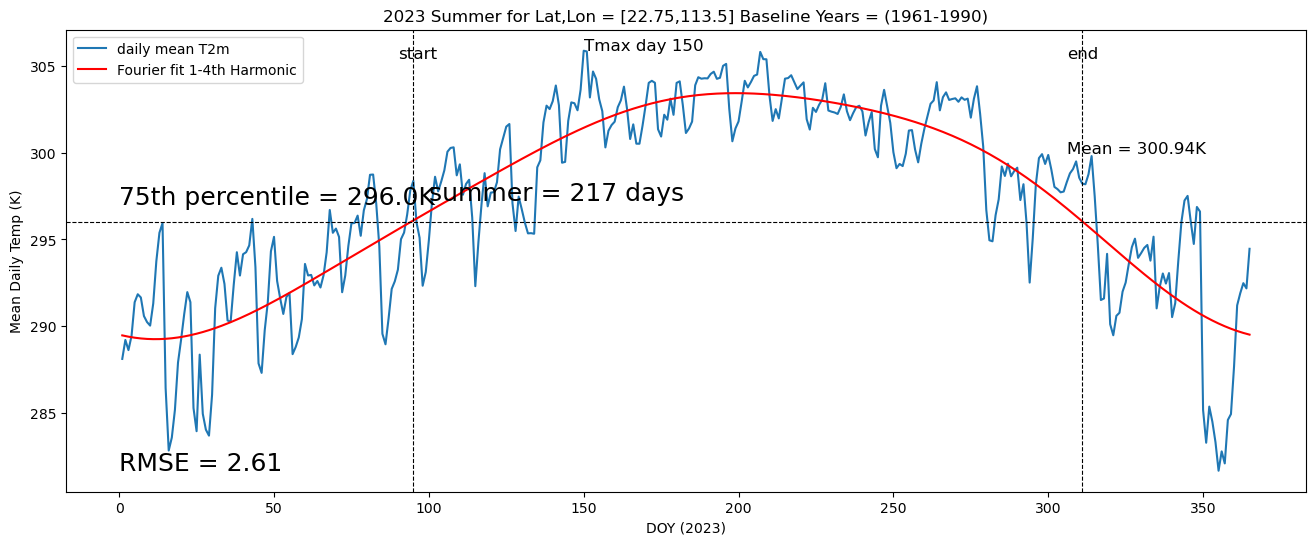

(95,
 311,
 150,
 1091.0107421875,
 217,
 2.610610008239746,
 0.0,
 300.9442443847656,
 5.455053710937477)

In [131]:
# change threshold to 22.9 C to see what the length for 2023 would be
thresh22 = thresh - 5

# Guangzhou
input_lat = 22 + 45/60 # midpoint of those latitude values above
input_lon = 113.5 # midpoint of those longitudes above
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = thresh22 #c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs


#### Lake Superior middle (47.7N, 87W)

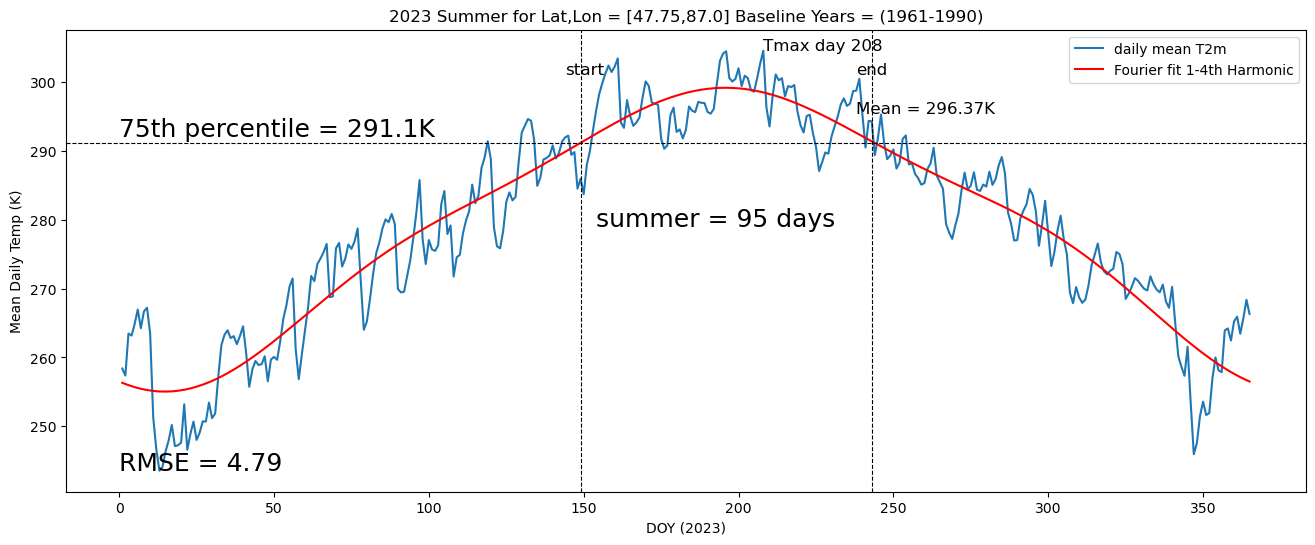

(149,
 243,
 208,
 523.8578186035156,
 95,
 4.790683269500732,
 0.0,
 296.3655090332031,
 6.311539983174896)

In [33]:

# Lake Superior - checking for shape of distribution

input_lat = 47.7 
input_lon = 87 
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs


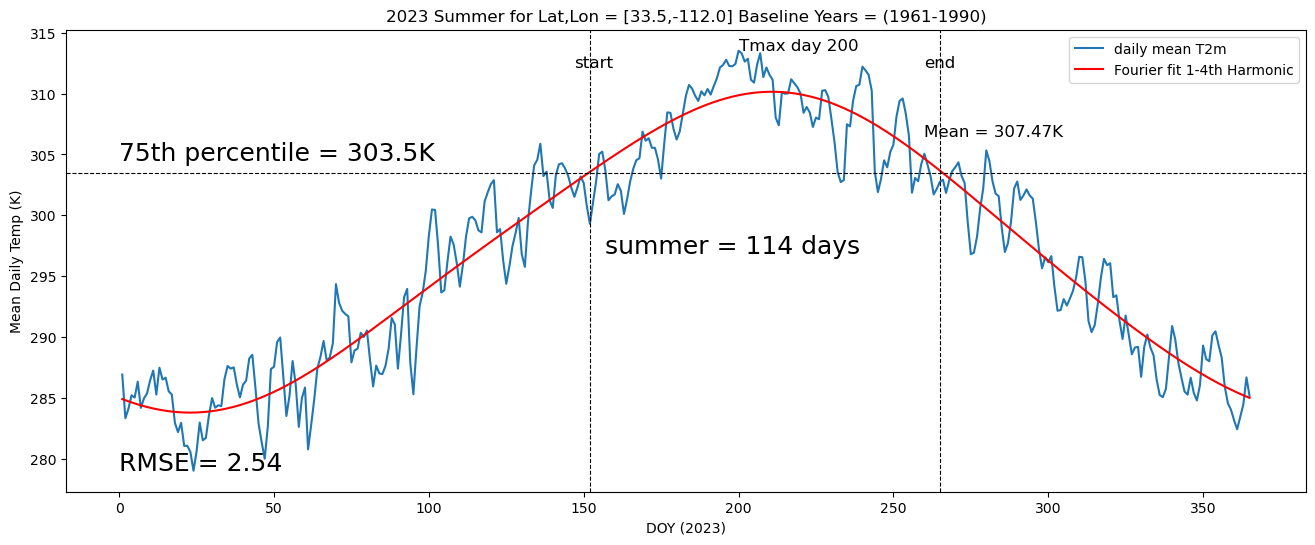

(152,
 265,
 200,
 483.3031921386719,
 114,
 2.5371434688568115,
 0.0,
 307.47076416015625,
 5.311024089435932)

In [34]:
# Phoenix
input_lat = 33+28/60
input_lon = -112 - 4/60
curr = ds.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon, method="nearest")
thresh = c_75.sel(lat=input_lat, lon=input_lon, method="nearest")
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

## *********

## ********** NEED to run all years now and then update "AnalyzeTrends" script to output the 1961-2023 summer stats aggregated file for analysis

## Main Loop: loop through multiple years to generate summer stats

In [8]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(2024, 2026,1)

process_yrs

array([2024, 2025])

In [9]:
%%time

# Runtime: 32.5 min for 1 year
# 3h 19m for 6 years
# 8h 50m hrs for 16 years

# loop thru the years in the defined array above
for input_year in process_yrs:

    start = dt.now()

    # get this year and next year's daily mean t2m data
    if input_year <= 1990:
        file_path = '../../../Data/ERA5-global/Baseline/' + str(input_year) + '/*.nc'
    else:
        file_path = '../../../Data/ERA5-global/Analysis/' + str(input_year) + '/*.nc'
    ds = xr.open_mfdataset(file_path)

    if input_year+1 <= 1990:
        file_path_next = '../../../Data/ERA5-global/Baseline/' + str(input_year+1) + '/*.nc'
    else:
        file_path_next = '../../../Data/ERA5-global/Analysis/' + str(input_year+1) + '/*.nc'
    dsnext = xr.open_mfdataset(file_path_next)

    # remove leap day by averaging Feb 28 & 29 together before dropping Feb 29
    ds = HandleLeapYears(ds)
    dsnext = HandleLeapYears(dsnext)

    # load into memory to speed up the summer stats processing
    ds.load()
    dsnext.load()

    # empty data arrays for summer stats
    summerlength = xr.DataArray(np.zeros((num_lat,num_lon)), 
                                coords=[loop_lats, loop_lons], 
                                dims=['lat','lon'])
    summerstart = xr.DataArray(np.zeros((num_lat,num_lon)), 
                               coords=[loop_lats, loop_lons], 
                               dims=['lat','lon'])
    summerend = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermax = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerheat = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerrmse = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summerr2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermean = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    summermeanhs = xr.DataArray(np.zeros((num_lat,num_lon)), 
                             coords=[loop_lats, loop_lons], 
                             dims=['lat','lon'])
    
    # add attributes
    summerstart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
    summerstart.attrs["units"] = "Day of year"
    
    summerend.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
    summerend.attrs["units"] = "Day of year"
    
    summerlength.attrs["long_name"] = "Duration of summer for the year"
    summerlength.attrs["units"] = "Days"
    
    summermax.attrs["long_name"] = "Day of max mean temp during summer for the year"
    summermax.attrs["units"] = "Day of year"
    
    summerheat.attrs["long_name"] = "Accumulated heat during summer for the year"
    summerheat.attrs["units"] = "Degree-Days"
    
    summerrmse.attrs["long_name"] = "Root mean squared error of Fourier fit"
    summerrmse.attrs["units"] = "Degrees [K]"
    
    summerr2.attrs["long_name"] = "Coefficient of determination (R-squared) of Fourier fit [NOT USED]"
    summerr2.attrs["units"] = "Variance explained"

    summermean.attrs["long_name"] = "Mean temperature during the summer period"
    summermean.attrs["units"] = "Degrees [K]"

    summermeanhs.attrs["long_name"] = "Mean HS temperature during the summer period"
    summermeanhs.attrs["units"] = "Degrees [K]"

    ## now that I've added RMSE and R^2 - these loops take ~27 min with heat and tmax

    # loop through all of the lat,lon of interest
    for input_lat in loop_lats:
        for input_lon in loop_lons:
            # get threshold from c_75
            thresh = c_75.sel(lat=input_lat,lon=input_lon)
    
            # all the temps for that grid cell over time for this year and next (for SH)
            curr = ds.t2m.sel(lat=input_lat,lon=input_lon) 
            nxt = dsnext.t2m.sel(lat=input_lat, lon=input_lon)
    
            # build summer stats for the grid cell and produce the plot if desired (currently False)
            start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, False, True, True)
            
            # xarray requires strange indexing in order to replace values by coordinate
            summerstart.loc[input_lat, input_lon] = start_day
            summerend.loc[input_lat, input_lon] = last_day
            summermax.loc[input_lat, input_lon] = day_of_max
            summerheat.loc[input_lat, input_lon] = acc_heat
            summerlength.loc[input_lat, input_lon] = summer_length
            summerrmse.loc[input_lat, input_lon] = rmse
            summerr2.loc[input_lat, input_lon] = r2
            summermean.loc[input_lat, input_lon] = mean_temp
            summermeanhs.loc[input_lat, input_lon] = mean_hs
            

    # save it out
    sum_ds = xr.Dataset(data_vars={'SummerStart':summerstart,
                               'SummerEnd':summerend,
                               'SummerTmax':summermax,
                               'SummerHeat':summerheat,
                               'SummerLength':summerlength,
                               'SummerRMSE':summerrmse,
                               'SummerR2':summerr2,
                                'SummerMeanT':summermean,
                                   'SummerMeanHS':summermeanhs})
    output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/'+str(input_year)+'_summer_stats.nc'
    sum_ds.to_netcdf(output_path)

    # plots for the year
    ##############
    # Global summer mean temp for the year
    # fig = plt.figure(figsize=(12,6))
    
    # # assign axis and def projection to use
    # ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))
    
    # # add coastlines and grid
    # ax.coastlines()
    # ax.gridlines()
    
    # sum_ds.SummerMeanT.plot(
    #     ax=ax,
    #     transform=ccrs.PlateCarree(), # assign map projection
    #     vmin=250,
    #     vmax=320, # define range to include an entire year
    #     cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
    # )
    
    # plt.title("Summer Mean Temp for "+str(input_year))#+" using 1961-1990 baseline")
    # #plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
    # plt.show()

    end = dt.now()
    elapsed = (end-start).total_seconds()/60.0
    print("Time for "+str(input_year)+" :"+str(elapsed)+" min")

Time for 2024 :35.28002635 min
Time for 2025 :35.067912066666665 min
CPU times: user 1h 9min 25s, sys: 44.6 s, total: 1h 10min 9s
Wall time: 1h 10min 20s


33.166666666666664